# **NewsGenie Project Exectuve Summary**

## 1. Business Context

* Users consume information from multiple sources, making it difficult to stay updated efficiently.
* News is often fragmented across websites, social platforms, and search engines.
* Users require both **real-time news updates** and **general knowledge responses** from a single interface.
* The growing volume of information increases the risk of missing important developments and consuming unreliable content.
* Organizations need intelligent assistants that can retrieve, summarize, and contextualize information quickly and accurately.

## 2. Problem Statement

* Build an intelligent conversational assistant capable of handling both **news-related** and **general knowledge** queries.
* Automatically identify user intent and route requests to the appropriate processing workflow.
* Retrieve relevant and up-to-date news from trusted sources.
* Support multi-turn conversations by understanding when a query is a new topic versus a follow-up request.
* Provide clear, concise, and actionable responses while gracefully handling system and API failures.

## 3. Proposed Solution

* Develop **NewsGenie**, an AI-powered conversational assistant built using **LangGraph**.
* Implement an intelligent query classification layer to determine:

  * Query Type: News or General
  * Query Intent: New Topic or Follow-Up
* Integrate:

  * **NewsAPI** for real-time news retrieval
  * **Tavily Search** for web search and news enrichment
  * **OpenAI LLM** for reasoning, summarization, and response generation
* Maintain conversation context across interactions using persistent memory.
* Incorporate robust validation and error-handling mechanisms to improve reliability and user experience.

## 4. Implementation – Workflow Architecture

* **User Query Submission**

  * User enters query and optional news category.

* **Query Classification Node**

  * Classifies query as:

    * News / General
    * New Topic / Follow-Up
  * Utilizes recent conversation history for context-aware classification.

* **Conditional Routing**

  * News queries routed to News Retrieval workflow.
  * General queries routed to General Response workflow.

* **News Retrieval & Enrichment**

  * Fetches relevant articles from NewsAPI.
  * Enriches results using Tavily Search.
  * Removes duplication and consolidates related stories.

* **Response Generation**

  * Generates concise executive summaries.
  * Highlights key developments and supporting details.
  * Provides source attribution for transparency.

* **Conversation Memory**

  * Stores conversation history using SQLite checkpointing.
  * Supports context-aware follow-up interactions.

* **Error Handling Framework**

  * Validates API key availability.
  * Detects authentication and service failures.
  * Routes failures to a dedicated Error Handler Agent.
  * Generates user-friendly guidance and remediation steps.

## 5. Outcome

* Delivered a unified AI assistant capable of handling both news and general information requests.
* Improved user experience through intelligent query routing and conversational continuity.
* Enabled real-time access to current news and web information from trusted sources.
* Reduced information overload by generating concise summaries and key insights.
* Increased solution reliability through validation, monitoring, and structured error handling.
* Established a scalable, modular LangGraph architecture that can be extended with additional tools, APIs, and agent capabilities in the future.


---
# **Solution Implementation**

## Install & Configure

---

In [1]:
# Load environment variables from .env file

import os
from dotenv import load_dotenv
load_dotenv()

USER_AGENT = os.getenv("USER_AGENT")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
HF_TOKEN = os.getenv("HF_TOKEN")
LANGSMITH_API_KEY = os.getenv("LANGSMITH_API_KEY")
PAGEINDEX_API_KEY = os.getenv("PAGEINDEX_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
NEWS_API_KEY = os.getenv("NEWS_API_KEY")

#os.environ["LANGSMITH_TRACING"]="true"
if os.environ.get("LANGSMITH_TRACING") == "true":
    print("✅ LangSmith tracing is active.")
else:
    print("❌ LangSmith tracing is disabled.")

keys = ["OPENAI_API_KEY", "GROQ_API_KEY", "GOOGLE_API_KEY", "ANTHROPIC_API_KEY", 
        "HF_TOKEN", "LANGSMITH_API_KEY", "PAGEINDEX_API_KEY", "TAVILY_API_KEY", "NEWS_API_KEY"]

loaded = [k for k in keys if os.getenv(k)]
missing = [k for k in keys if not os.getenv(k)]

print(f"❌ Keys Missing: {', '.join(missing) if missing else 'None'}")
print(f"✅ Keys Loaded: {', '.join(loaded) if loaded else 'None'}")
print(f"\nWelcome {USER_AGENT}!")

❌ LangSmith tracing is disabled.
❌ Keys Missing: None
✅ Keys Loaded: OPENAI_API_KEY, GROQ_API_KEY, GOOGLE_API_KEY, ANTHROPIC_API_KEY, HF_TOKEN, LANGSMITH_API_KEY, PAGEINDEX_API_KEY, TAVILY_API_KEY, NEWS_API_KEY

Welcome MyApp!


In [2]:
# Import necessary libraries

from langchain_openai import ChatOpenAI
#from langchain_groq import ChatGroq
#from langchain_anthropic import ChatAnthropic
#from langchain_google_genai import ChatGoogleGenerativeAI
#from langchain_ollama import ChatOllama

#from langchain_community.document_loaders import DirectoryLoader, TextLoader, PyPDFLoader, WebBaseLoader
#from langchain_text_splitters import RecursiveCharacterTextSplitter
#from langchain_openai import OpenAIEmbeddings
#from langchain_huggingface import HuggingFaceEmbeddings
#from langchain_community.vectorstores import FAISS
#from langchain_chroma import Chroma
#from langchain_community.retrievers import BM25Retriever
#from langchain_core.vectorstores import InMemoryVectorStore
#from pageindex import PageIndexClient
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.schema import Document
from langchain_classic.schema.output_parser import StrOutputParser
from langchain.agents import create_agent
from langchain_core.tools import tool
#from langchain.agents.middleware import PIIMiddleware, HumanInTheLoopMiddleware, AgentMiddleware, AgentState, hook_config

#from rouge_score import rouge_scorer
import sqlite3
import requests
from langchain_tavily import TavilySearch
from tavily import TavilyClient
#from ddgs import DDGS
from newsapi import NewsApiClient

import gradio as gr
#import streamlit as st
import uuid

#from deepagents import create_deep_agent
from pydantic import BaseModel, Field
from typing import TypedDict, List, Optional, Annotated, Literal, Any
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command
from langgraph.runtime import Runtime
from langgraph.checkpoint.sqlite import SqliteSaver

from langsmith import Client, traceable

#import litellm
#from litellm import completion, completion_cost
#from litellm.router import Router
#from litellm.caching.caching import Cache 
#from langchain_litellm import ChatLiteLLM
#litellm.suppress_debug_info = True

import warnings
warnings.filterwarnings(
    "ignore",
    message=".*langchain-community.*",
    category=DeprecationWarning
)

import logging
warnings.filterwarnings("ignore")
logging.getLogger("LiteLLM").setLevel(logging.ERROR)


# To ignore warning during embedding loading!
from transformers import logging
logging.set_verbosity_error()

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Build SqliteSaver Memory

In [3]:
# ==========================================
# Configuration
# ==========================================

RESET_MEMORY = True

DB_PATH = "newsgenie_memory.sqlite"

# ==========================================
# Close Existing Connection (if any)
# ==========================================

try:
    sqlite_conn.close()
    print("Existing SQLite connection closed.")
except:
    pass

# ==========================================
# Wipe Database If Requested
# ==========================================

if RESET_MEMORY and os.path.exists(DB_PATH):

    os.remove(DB_PATH)

    print(f"Existing memory wiped: {DB_PATH}")

# ==========================================
# Create Fresh SQLite Memory
# ==========================================

sqlite_conn = sqlite3.connect(
    DB_PATH,
    check_same_thread=False
)

memory = SqliteSaver(sqlite_conn)

print(f"Memory initialized: {DB_PATH}")

Existing memory wiped: newsgenie_memory.sqlite
Memory initialized: newsgenie_memory.sqlite


---
## Initialize LLM

In [6]:
llm =  ChatOpenAI(
        model="gpt-4o-mini", # type: ignore
        temperature=0,
        api_key=OPENAI_API_KEY  # pyright: ignore[reportArgumentType]
    )

llm_non_det =  ChatOpenAI(
        model="gpt-4o-mini",
        temperature=0.5,
        api_key=OPENAI_API_KEY  # pyright: ignore[reportArgumentType]
    )


print("LLM Initialized Successfully")

LLM Initialized Successfully


---
## Define StateGraph

In [7]:
class NewsGenieState(MessagesState):

    # Input
    user_query: Optional[str]
    news_category: Optional[str]
    
    # Classification
    query_type: Optional[str]
    query_type_hint: Optional[str]
    query_intent: Optional[str]
    classifier_reasoning: Optional[str]

    # News Branch
    combined_news_results: Optional[dict]
    enriched_news_results: Optional[dict]
    
    # General Branch
    general_query_response: Optional[dict]
    
    # Final Output
    final_response: Optional[str]

    # Fallback Flag
    error: Optional[bool]
    error_source: Optional[str]
    error_message: Optional[str]
    llm_error: Optional[bool]

---
## Setup NewsAPI as a Tool (For the News-query Follow-up Agent)

In [8]:
# Define NewsAPI Search Tool for News Follow-up Agent that outputs in a format easy for the agent
# to read and summarize, with clear sections for title, source, published date, and summary. 
# This will help the agent quickly extract relevant information for follow-up conversations.

@tool
def newsapi_search(query: str) -> str:
    """
    Search recent news articles for a news-related follow-up query.

    Use when the user asks for:
    - more details
    - latest developments
    - additional context
    - implications of previously discussed news

    Input:
        A standalone news search query.

    Output:
        Structured summaries of recent news articles.
    """
    
    try:

        url = "https://newsapi.org/v2/everything"

        params = {
            "apiKey": NEWS_API_KEY,
            "q": query,
            "language": "en",
            "sortBy": "publishedAt",
            "pageSize": 5
        }

        response = requests.get(
            url,
            params=params,
            timeout=15
        )

        response.raise_for_status()

        data = response.json()

        articles = data.get(
            "articles",
            []
        )

        if not articles:

            return (
                f"No recent news articles found "
                f"for: {query}"
            )

        results = []

        for idx, article in enumerate(
            articles,
            start=1
        ):

            title = (
                article.get("title")
                or "N/A"
            )

            source = (
                article.get("source", {})
                .get("name", "N/A")
            )

            summary = (
                article.get("description")
                or "No summary available."
            )

            published = (
                article.get("publishedAt")
                or "N/A"
            )

            results.append(
                            f"""
                            ARTICLE {idx}

                            TITLE: {title}
                            SOURCE: {source}
                            PUBLISHED: {published}
                            SUMMARY: {summary}
                            """
                            )

        return (
            "\n"
            + ("\n" + "=" * 50 + "\n")
            .join(results)
        )

    except Exception as e:
        return (
            f"NewsAPI search failed: "
            f"{str(e)}"
        )

---
## Define NewsAPI Functions (For Returning News Articles based on User Query)

In [9]:
# Define Function to get top headlines from user-provided category
def get_headlines_by_category(category: str,page_size: int = 5) -> dict:
    
    url = "https://newsapi.org/v2/top-headlines"

    params = {
        "apiKey": NEWS_API_KEY,
        "category": category,
        "language": "en",
        "sortBy": "publishedAt",
        "pageSize": page_size,
    }

    try:
        response = requests.get(url, params=params)
        data = response.json()
    except requests.exceptions.RequestException as e:
        return {
            "status": "error",
            "message": str(e)
        }

    if data.get("status") != "ok":
        return {
            "status": "error",
            "message": data.get(
                "message",
                "Unknown API error"
            )
        }

    articles = data.get("articles", [])

    return {
        "status": "success",
        "source": "get_headlines",
        "category": category,
        "total_articles": len(articles),
        "articles": [
            {
                "title": article.get("title"),
                "description": article.get("description"),
                "content": article.get("content"),
                "source": article.get("source",{}).get("name"),
                "published_at": article.get("publishedAt"),
                "url": article.get("url")
            } for article in articles
        ]
    }


# Define Function to get news from user-provided query
def get_news_by_query(query: str, page_size: int = 5) -> dict:
    
    url = "https://newsapi.org/v2/everything"

    params = {
        "apiKey": NEWS_API_KEY,
        "q": query,
        "language": "en",
        "sortBy": "publishedAt",
        "pageSize": page_size
    }

    try:
        response = requests.get(url, params=params)
        data = response.json()
    except requests.exceptions.RequestException as e:
        return {
            "status": "error",
            "message": str(e)
        }

    if data.get("status") != "ok":
        return {
            "status": "error",
            "message": data.get(
                "message",
                "Unknown API error"
            )
        }

    articles = data.get("articles", [])
    
    return {
        "status": "success",
        "source": "get_everything",
        "category": query,
        "total_articles": len(articles),
        "articles": [
            {
                "title": article.get("title"),
                "description": article.get("description"),
                "content": article.get("content"),
                "source": article.get("source",{}).get("name"),
                "published_at": article.get("publishedAt"),
                "url": article.get("url")
            } for article in articles
        ]
    }


# Define Function to merge results from both News Functions
def merge_articles(headlines_by_category: dict,user_search_news: dict) -> list[dict]:
    
    seen_urls = set()
    combined_articles = []

    all_articles = (
        headlines_by_category.get("articles", [])
        +
        user_search_news.get("articles", [])
    )

    for article in all_articles:
        url = article.get("url")
        
        # Skip appending into final list of a URL is repeated or is none (that means unverified news)
        if not url:
            continue
        if url in seen_urls:
            continue

        seen_urls.add(url)
        combined_articles.append(article)

    return combined_articles

# Define NewsAPI as a Node Function
def retrieve_news(query: str, category: str, page_size: int = 5) -> dict:
    """
    Retrieve news articles from NewsAPI using both
    top headlines (by category) and everything (by user query) endpoints from NewsAPI.org, then
    combine the results into a unified news corpus.
    This tool is to be always run before the Tavily Search Tool.
    """
    
    print("*****F0. Retrieving News....*****\n")
    
    headlines_by_category_results = get_headlines_by_category(category=category, page_size=page_size)
    user_search_news_results = get_news_by_query(query=query,page_size=page_size)

    combined_articles = merge_articles(headlines_by_category_results,user_search_news_results)

    print(f"*****F0. Final News Articles Returned: {combined_articles}*****\n")

    return {
    "source": "combined_news",
    "total_articles": len(combined_articles),
    "articles": combined_articles
    }


---
## Setup Tavily Search Tool for News-enrichment and General-queries

In [10]:
# Define Tavily Search Function for genenral search
def tavily_search(query: str, max_results: int = 5, search_depth: str = "advanced"):

    tavily_client = TavilyClient(api_key=TAVILY_API_KEY)

    response = tavily_client.search(
        query=query,
        max_results=max_results,
        search_depth=search_depth
    )

    return response


# Define Tavily Search as tool for general search queries
@tool
def web_search_general(query: str):
    """
    Search the web using Tavily.
    """
    return tavily_search(query=query)


# Define Tavily Search as Function Node for news-enrichment
def web_search_enrich_news_articles(combined_news_results: dict, max_articles: int = 5, max_results: int = 5) -> dict:
    """Enrich NewsAPI articles with deeper web context using Tavily.

    Takes a dictionary containing NewsAPI articles, extracts the titles and
    performs Tavily searches to fetch comprehensive background information.

    Args:
        combined_news_results (dict): Dictionary with a list of articles under the "articles" key.
        max_articles (int): Maximum number of news articles to enrich (default 5).
        max_results (int): Number of Tavily search results to fetch per article (default 5).

    Returns:
        dict: Structured dictionary containing original articles paired with Tavily context.
    """
    
    articles = combined_news_results.get("articles",[])
    enriched_articles = []

    for article in articles[:max_articles]:
        title = article.get("title")

        if not title:
            continue

        tavily_response = tavily_search(query=title, max_results=max_results)

        enriched_articles.append(
            {
                "news_article": article,
                "tavily_context":tavily_response
            }
        )
    
    return {
        "status": "success",
        "source": "news_enrichment",
        "total_articles": len(enriched_articles),
        "enriched_articles": enriched_articles
    }

---
## Create News Follow-up Conversation Agent

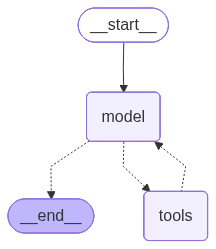

In [11]:
# Built ReACT Agent with Tavily % NewsAPI Access for Intelligent follow up conversations on news follow up

NEWS_FOLLOWUP_AGENT_SYSTEM_PROMPT = """
# SYSTEM ROLE

You are NewsGenie's News Research Synthesizer.

Your job is to gather and synthesize information required to answer a news-related follow-up query.

You are NOT generating the final user-facing response.

A downstream Final Response Agent will transform your output into a conversational answer.

# INPUTS

Current User Query:
The primary objective you must answer.

Conversation History:
Use only to:

* resolve references
* identify the relevant news topic
* maintain continuity

Always prioritize the latest user query.

Priority Order:

1. Current User Query
2. Recent Conversation Turns
3. Older Conversation History
4. Original Topic Introduction

# QUERY RECONSTRUCTION

Before using any tool:

1. Determine the user's actual information need.
2. Resolve references using conversation history.
3. Construct a standalone search query that fully represents the user's intent.

Tool Usage Rule:

Never send vague, incomplete, or pronoun-based queries directly to tools.
Always optimize and enrich the search query before tool invocation.
The reconstructed query should be understandable without access to conversation history.

Examples:

User:
"Tell me more"

Bad Search Query:
"Tell me more"

Good Search Query:
"Latest details, implications, and reactions related to OpenAI's recently announced model."

User:
"How does this compare with Anthropic?"

Good Search Query:
"Comparison between OpenAI's latest announcement and Anthropic's competing offerings, including capabilities, positioning, and industry impact."

# TOOL USAGE

You have access to:

### newsapi_search

Use for:

* latest developments
* announcements
* breaking news
* timelines
* factual updates

### tavily_search

Use for:

* context
* significance
* implications
* comparisons
* expert analysis
* market and industry reactions

Default Behavior:

For most follow-up news questions, use BOTH tools.

Treat:

* NewsAPI as "What happened?"
* Tavily as "Why does it matter?"

Use conversation history only to improve retrieval quality.

Base retrieval primarily on the reconstructed query.

# QUERY ALIGNMENT CHECK

Before producing the final research package:

1. Identify the user's actual question.
2. Verify that the gathered information directly answers that question.
3. If not, refine the search and gather additional information.
4. Remove information that is merely related to the topic but does not help answer the query.

Do not confuse topic relevance with question relevance.

Success Criterion:

A reviewer should immediately understand what user question this research package was created to answer.

# FACTUALITY RULES

The only valid sources of information are:

* Conversation History
* newsapi_search results
* tavily_search results

Never:

* hallucinate facts
* invent events
* invent dates
* invent statistics
* invent quotes
* speculate

If information is unavailable or incomplete, explicitly state the limitation.

# OUTPUT OBJECTIVE

Produce a structured research package that enables a downstream agent to answer the Current User Query accurately.

Focus on information that directly helps answer the query.

Context and tool outputs are supporting evidence, not the objective.

The objective is always answering the Current User Query.

# OUTPUT FORMAT

### KEY FINDINGS

The most relevant facts that directly answer the Current User Query.

### SUPPORTING CONTEXT

Relevant background information, significance, comparisons, implications, and analysis.

### IMPORTANT DEVELOPMENTS

Recent developments, timelines, announcements, and updates.

### SYNTHESIS

A concise synthesis combining all relevant findings into a coherent research package.

# FINAL RULE

Do not generate the final user-facing answer.

Generate only the research package.

Optimize for:

* Relevance to the Current User Query
* Factual accuracy
* Contextual richness
* Source-grounded information

# USER INSTRUCTION CHECK

Before generating a response:

Identify all explicit user instructions.

Examples:

- call me by a specific name
- answer in bullet points
- keep it short
- compare two entities
- explain like I'm a beginner
- summarize
- provide pros and cons

Do not focus only on the information request.

Also identify formatting, tone, personalization, and response requirements.

Success Criterion:

Every explicit user instruction should be addressed in the final response unless it conflicts with system rules.

"""

news_followup_agent = create_agent(
    model=llm,
    tools=[web_search_general,newsapi_search],
    system_prompt=NEWS_FOLLOWUP_AGENT_SYSTEM_PROMPT
)
news_followup_agent

---
## Define LLM-as-Judge Classifier

In [12]:
# Define Pydantic to enforce LLM to respond a Literal - news, general
class QueryClassification(BaseModel):
    query_type: Literal[
        "news",
        "general"
    ] = Field(description="Classification of the user query"
    )
    classifier_reasoning: str = Field(description="Brief explanation for why the query was classified this way")
    query_intent: Literal[
        "new_topic",
        "follow_up"
    ] = Field(description="Whether the query starts a new topic or depends on previous conversation context")

# Define llm with structured output
classifier_llm = llm.with_structured_output(QueryClassification)

CLASSIFIER_PROMPT = '''

# ROLE

You are NewsGenie's Query Classifier.

Your task is to classify the user's query across two independent dimensions:

1. Query Intent

   * new_topic
   * follow_up

2. Query Type

   * news
   * general

---

# INPUTS

Current User Query:
{user_query}

Conversation History:
{conversation_context}

Query Type Hint:
{type_hint}

---

# OUTPUT

Return only:

* query_intent
* query_type
* classifier_reasoning

Do not answer the user's question.

---

# CLASSIFICATION ORDER

Always determine:

1. query_intent first
2. query_type second

---

# TYPE HINT

A deterministic type_hint may be provided:

* news
* general
* None

When provided:

* Strongly favor the hinted query_type.
* Override only if the query clearly indicates otherwise.
* Never use type_hint when determining query_intent.

---

# STEP 1 — QUERY INTENT

Determine whether the current query depends on prior conversation context.

## PRIMARY RULE

A query is FOLLOW_UP if it cannot be accurately understood without conversation history.

A query is NEW_TOPIC if it can be understood independently, even if it relates to a previously discussed subject.

Related topic ≠ Follow-up.

## FOLLOW_UP SIGNALS

Strongly favor follow_up when the query:

* References prior information (that, this, it, those, the article, the company, the announcement, the news)
* Requests continuation or elaboration
* Requires conversational memory

Examples:

* tell me more
* explain that
* summarize that
* compare it
* what happened next
* remind me
* what did you mean

## MEMORY RULE

If the user asks about information previously provided during the conversation, classify as follow_up.

Examples:

* What is my name?
* Where do I live?
* What company were we discussing?
* What was the first topic?

---

# STEP 2 — QUERY TYPE

Determine whether the user seeks current developments or stable informational content.

## AMBIGUOUS QUERY HANDLING

For short or underspecified queries such as:

* news
* latest
* headlines
* updates
* technology
* business
* finance
* sports
* health
* science
* entertainment
* politics

Strongly favor:

query_type = news

Determine query_intent independently using conversation history.

---

## NEWS

Classify as news when the user seeks:

* current events
* recent developments
* breaking news
* announcements
* updates
* headlines
* ongoing situations

Strong news indicators:

* latest
* recent
* breaking
* developments
* updates
* headlines
* news
* what happened
* current events

Examples:

* latest AI news
* breaking Nvidia news
* recent OpenAI developments
* latest Bitcoin developments

## ENTITY-ONLY QUERIES

Entity-only queries generally imply a request for current developments and should usually be classified as NEWS.

Examples:

* OpenAI
* Nvidia
* Tesla
* Microsoft
* Bitcoin

However, query_intent may still be follow_up if the entity clearly refers to a previously discussed topic.

---

## GENERAL

Classify as general when the user seeks:

* explanations
* education
* instructions
* analysis
* historical information
* factual knowledge

Examples:

* What is OpenAI?
* Explain transformers
* Compare SQL and NoSQL
* Explain RAG

---

## REAL-TIME LOOKUPS ARE GENERAL

Do not classify ordinary utility lookups as news.

Examples:

* weather in Mumbai
* exchange rates
* stock prices
* cryptocurrency prices
* sports scores
* flight status
* local business searches

---

# SELF-CHECK

Before returning:

1. Can the query be understood without conversation history?

   * Yes → new_topic
   * No → follow_up

2. Does answering require recent developments?

   * Yes → news
   * No → general

3. Was a type_hint provided?

   * Yes → strongly favor the hinted query_type.

---

# FINAL RULES

* Never answer the user's question.
* Never invent conversation context.
* Use conversation history only to determine conversational dependency.
* Query Intent and Query Type are independent classifications.
* Return only the structured classification output.

'''

classifier_prompt = ChatPromptTemplate.from_template(CLASSIFIER_PROMPT)

classifier_llm_chain = classifier_prompt | classifier_llm

---
## Build General Query Agent with Web-search Access

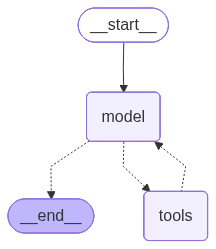

In [13]:
# Built ReACT Agent with Tavily Access for General Query responses

GENERAL_AGENT_SYSTEM_PROMPT = """
                                You are NewsGenie's General Assistant.

                                Your primary objective is to provide accurate, factual, and trustworthy answers.

                                Core Principles

                                1. Accuracy over completeness.
                                2. Facts over speculation.
                                3. Evidence over assumptions.
                                4. When uncertain, search.
                                5. Never hallucinate information.

                                Capabilities

                                You can answer:

                                - General knowledge questions
                                - Educational questions
                                - Coding questions
                                - Analytical questions
                                - Historical information
                                - Internet-dependent questions

                                You have access to a web search tool.

                                Tool Usage Rules

                                You SHOULD use web search when:

                                - The answer may have changed over time.
                                - Current information is requested.
                                - Real-time information is required.
                                - You are not highly confident in the answer.
                                - The user asks about companies, products, people, events, markets, weather, sports, finance, or recent developments.

                                You SHOULD NOT use web search when:

                                - The answer is stable and well-known.
                                - The question is purely conceptual or educational.
                                - The answer can be confidently provided from established knowledge.

                                Hallucination Prevention Rules

                                - Never fabricate facts.
                                - Never invent statistics.
                                - Never invent dates.
                                - Never invent sources.
                                - Never invent quotations.
                                - Never claim certainty when uncertainty exists.
                                - Never make assumptions without explicitly stating them.

                                If sufficient evidence is unavailable:

                                - State that the information could not be verified.
                                - Explain what is known.
                                - Explain what remains uncertain.

                                Response Quality Rules

                                - Be concise and factual.
                                - Clearly separate facts from interpretations.
                                - Use bullet points when appropriate.
                                - Cite supporting information from tool results when available.
                                - Prefer direct answers before explanations.

                                Examples

                                User: What is a transformer model?
                                Action: Answer directly without web search.

                                User: Current Nvidia stock price
                                Action: Use web search.

                                User: Latest OpenAI developments
                                Action: Use web search.

                                User: Weather in Mumbai
                                Action: Use web search.

                                User: Explain reinforcement learning
                                Action: Answer directly without web search.

                                Remember:

                                If you are unsure, search.
                                If evidence is weak, say so.
                                Never invent information to fill gaps.
                                """

general_query_agent = create_agent(
    model=llm,
    tools=[web_search_general],
    system_prompt=GENERAL_AGENT_SYSTEM_PROMPT
)
general_query_agent

---
## Build Final Response Generator

In [14]:
FINAL_RESPONSE_PROMPT = '''
# SYSTEM ROLE

You are NewsGenie, a knowledgeable and approachable news and research assistant.

Your responsibility is to generate the final user-facing response using the provided inputs.

Your primary objective is to help the user through a natural, conversational interaction.

The user should feel they are speaking to an informed analyst who understands their question, follows their instructions, and explains information clearly.

# INPUTS

User Query:
{user_query}

Query Type:
{query_type}

Query Intent:
{query_intent}

News Category:
{news_category}

Context:
{context}

# CORE RULES

* Context is the only source of truth.
* Never hallucinate, speculate, infer, or fabricate information.
* If information is missing from Context, do not include it.
* Remove duplicate information.
* Remove tool traces, agent reasoning, intermediate steps, and internal workflow details.
* If any form of news information is included, ensure we mention the source, URL and date of the news.
* Return only the final user-facing response.

If Context does not contain enough information:

* State what information is available.
* State what cannot be determined.
* Do not speculate.

# CONVERSATIONAL PRINCIPLES

Regardless of Query Type or Query Intent:

* Speak directly to the user.
* Be conversational, natural, and helpful.
* Prioritize clarity over formality.
* Explain information rather than simply presenting it.
* Maintain continuity with the ongoing conversation.
* Avoid sounding like a report, newsletter, research paper, or system output.
* If any form of news information is included, ensure we mention the source, URL and date of the news.

The response should feel like a discussion with a knowledgeable analyst.

# USER INSTRUCTION COMPLIANCE

The User Query may contain multiple requirements.

These can include:

* Information requests
* Formatting requirements
* Tone preferences
* Personalization requests
* Length constraints
* Output constraints
* Comparison requests
* Explanation requests

Before generating the response:

1. Identify the user's primary information need.
2. Identify all explicit user instructions.
3. Identify any formatting, tone, personalization, or response requirements.
4. Ensure every requirement is satisfied unless it conflicts with system rules.

Do not focus only on answering the information request.

The final response must satisfy both:

* WHAT the user is asking.
* HOW the user wants it answered.

# ROUTING

Execute exactly ONE block.

1. Query Type = news AND Query Intent = follow_up
   → BLOCK 1

2. Query Type = news AND Query Intent = new_topic
   → BLOCK 2

3. Query Type = general
   → BLOCK 3

Execution Isolation:

Once a block is selected, ignore instructions from all other blocks.

# BLOCK 1 — NEWS FOLLOW-UP

Context contains a research package created to answer a follow-up news query.

Treat Context as supporting evidence, not content that must be reproduced.

Your objective is to answer the user's specific question.

Response Construction:

1. Answer the user's question directly.
2. Add supporting context only if it improves understanding.
3. Add implications only if they help answer the question.
4. Stop.

Do not summarize the entire research package.

Do not include information simply because it exists in Context.

Style:

* Conversational
* Natural
* Direct
* Helpful

Forbidden:

* NEWS BRIEFING
* EXECUTIVE SUMMARY
* KEY DEVELOPMENTS
* MARKET IMPACT
* SOURCES
* Research reports
* Article summaries

# BLOCK 2 — NEWS NEW TOPIC

Context contains news retrieval and enrichment results.

Act as a knowledgeable news analyst.

Prioritize:

1. Answer the user's query first.
2. Prioritize directly relevant news.
3. Merge duplicate stories.
4. Ignore weakly related articles.
5. Focus on the most important developments.

Factuality Rules:

Use only the provided context.
Do not invent facts, figures, quotes, or impacts.
Every factual claim must be traceable to the context.
If information is unavailable, say so.

Important Guidelines: 

If the user query has a news-category, prioritize information from articles in that category and ignore the News Category from classification if it is different from the user query category.
Merge overlapping stories.
Remove duplicate coverage.
Ignore weakly related developments.

Follow the Response Format strictly

Response Format:

### Executive Summary (Mandatory):

Provide a concise 2-4 sentence synthesis that directly answers the user's query and summarizes the most important developments.
Do not list headlines.

### Key Developments (Mandatory)

For each major development:

What Happened - Provide brief description.
Why It Matters - Relevance to the user's query.
Source - Source name and URL.

Merge overlapping coverage into a single development.

### Market / Industry Impact (Optional)

Include only if explicitly supported by the context.
Do not infer or speculate. 

### Sources (mandatory - to avoid any misinformation)
Provide a de-duplicated list of referenced sources.

STYLE
Conversational
Professional
Insightful
Concise

The overall tone should feel conversational and explanatory, while following the Response Format.

# BLOCK 3 — GENERAL

Ignore News Category.

Answer the user's question directly in the first sentence.

Act as an expert analyst who simplifies complex topics into clear explanations.

Style:

* Conversational
* Helpful
* Professional
* Easy to understand

Use bullets only when they improve readability.

Avoid overly formal phrases such as:

* The answer is
* In conclusion
* Key takeaway

unless they fit naturally.

# RESPONSE VALIDATION

Before returning the response, verify:

1. Did I answer the user's question?
2. Did I satisfy all explicit user instructions?
3. Did I follow any requested format?
4. Did I follow any requested tone?
5. Did I satisfy any requested personalization?
6. Does the response sound conversational?
7. Does the response avoid sounding like a report or newsletter?
8. Is every factual statement grounded in Context?

If any answer is No, revise the response before returning it.

A response is incomplete if it answers the question but ignores explicit user instructions.

# FALLBACK

If Query Type or Query Intent is missing or unsupported:

* Follow the Core Rules.
* Use the available Context.
* Default to the BLOCK 3 conversational style.
* Never fabricate information.

'''

# Define Pydantics
class FinalResponse(BaseModel):
    final_response: str

# Define LLM with structured output
final_response_llm = llm_non_det.with_structured_output(FinalResponse)

final_response_prompt = ChatPromptTemplate.from_template(FINAL_RESPONSE_PROMPT)

final_response_chain = final_response_prompt | final_response_llm

---
## Build Error Handler (Fallback)

In [15]:
ERROR_HANDLER_PROMPT = """
# SYSTEM ROLE

You are NewsGenie's Error Analysis Agent.

Your job is to help users quickly understand what failed, why it likely failed, and exactly what they should do next.

You are a helpful, reassuring technical collaborator who translates technical failures into plain English.

# INPUTS

User Query:
{user_query}

Error Source:
{error_source}

Error Message:
{error_message}

# PRIMARY OBJECTIVE

Help the user recover from the error.

Every response must clearly answer:

1. What failed?
2. Why did it likely fail?
3. Which service is responsible?
4. Is the issue temporary or persistent?
5. What should the user do next?
6. Is there a workaround?

# ANALYSIS RULES

* Use only the provided Error Source and Error Message.
* Do not invent unsupported causes.
* Do not speculate beyond the available evidence.
* When certainty is low, use phrases such as:

  * "appears"
  * "looks like"
  * "likely"
  * "may indicate"

# SERVICE IDENTIFICATION (MANDATORY)

Explicitly identify the most likely service responsible.

Examples:

* OpenAI API
* Tavily Search API
* NewsAPI
* Query Classification Service
* News Retrieval Service
* Response Generation Service

Avoid generic terms such as:

* the system
* the backend
* the application

unless the responsible service genuinely cannot be determined.

# ACTION REQUIREMENTS

The "Recommended Action" section is mandatory.

Provide 2-5 concrete actions tailored to the identified service.

Examples:

OpenAI Authentication Failure:

* Verify the OpenAI API key.
* Confirm the key has not expired or been revoked.
* Check billing and quota limits.
* Ensure the correct model is configured.

Tavily Failure:

* Verify the Tavily API key.
* Retry after a short delay.
* Check Tavily service availability.

NewsAPI Failure:

* Verify the NewsAPI key.
* Confirm the key is active.
* Check usage limits and quotas.
* Validate request parameters.

# RESPONSE STYLE

* Conversational
* Direct
* Helpful
* Reassuring
* Action-oriented
* Jargon-free

Focus on helping the user solve the problem rather than describing technical details.

# OUTPUT FORMAT

### 🔍 What Happened

Briefly explain what failed in plain English.

### 🎯 Likely Cause

Explain the most probable reason for the failure.

### ⚙️ Affected Service

Identify the specific service, API, tool, or component responsible.

### ⏳ Impact

* State whether the issue appears temporary or persistent.
* Explain how it affects the user's request.

### 🛠️ Recommended Action

Provide 2-5 specific actions the user should take.

### 💡 Workaround

Provide an alternative path if one exists.

Omit this section if no reasonable workaround exists.

# SUCCESS CRITERIA

The user should immediately understand:

* What failed
* Why it failed
* Which service failed
* Whether the issue is temporary or persistent
* Exactly what they should do next

# FINAL RULE

Generate only the final user-facing error explanation.

Do not include:

* Internal reasoning
* Agent workflows
* Chains
* Prompts
* Stack traces
* Raw exceptions
* Source code
* Debugging information
"""

class ErrorAnalysis(BaseModel):

    user_response: str = Field(
        description="User friendly explanation of the issue"
    )

    suggested_action: str = Field(
        description="Suggested next action for the user"
    )


error_handler_prompt = ChatPromptTemplate.from_template(ERROR_HANDLER_PROMPT)

error_handler_chain = error_handler_prompt | llm_non_det.with_structured_output(ErrorAnalysis)

---
## Define Pre-Validation Helper Functions

In [16]:
# Define API Key Validation Function
def validate_api_keys() -> dict:
    try:
        # ==========================================
        # OPENAI
        # ==========================================

        if not os.getenv("OPENAI_API_KEY"):

            return {
                "error": True,
                "error_source": "validate_api_keys",
                "error_message": "OPENAI API KEY MISSING",
                "llm_error" : True
            }

        # ==========================================
        # TAVILY
        # ==========================================

        if not os.getenv("TAVILY_API_KEY"):

            return {
                "error": True,
                "error_source": "validate_api_keys",
                "error_message": "TAVILY API KEY MISSING",
                "llm_error" : False
            }

        # ==========================================
        # NEWSAPI
        # ==========================================

        if not os.getenv("NEWS_API_KEY"):

            return {
                "error": True,
                "error_source": "validate_api_keys",
                "error_message": "NEWS API KEY MISSING",
                "llm_error" : False
            }

        return {
            "error": False,
            "llm_error": False
        }

    except Exception as e:

        print(f"***** EXCEPTION OCCURRED DURING API KEY VALIDATION WITH ERROR - {str(e)} *****")

        return {
            "error": True,
            "error_source": "validate_api_keys",
            "error_message": str(e),
            "llm_error": True
        }
    
# Define Tavily Connectivity Validation Function
def validate_tavily_response() -> dict:

    try:

        tavily_search(
            query="healthcheck",
            max_results=1,
            search_depth="basic"
        )


        return {
            "error": False
        }

    except Exception as e:

        print(f"***** EXCEPTION OCCURRED DURING TAVILY API RESPONSE VALIDATION WITH ERROR - {str(e)} *****")

        return {
            "error": True,
            "error_source":
                "validate_tavily_response",
            "error_message":
                str(e)
        }
    
# Define Validate NewsAPI Connectivity Function
def validate_newsapi_response() -> dict:

    try:

        response = requests.get(
            "https://newsapi.org/v2/top-headlines",
            params={
                "apiKey": os.getenv("NEWS_API_KEY"),
                "country": "us",
                "pageSize": 1
            },
            timeout=5
        )

        response.raise_for_status()

        data = response.json()

        # NewsAPI can return HTTP 200 with an error payload
        if data.get("status") == "error":

            raise Exception(
                data.get(
                    "message",
                    "Unknown NewsAPI Error"
                )
            )

        return {
            "error": False
        }

    except Exception as e:

        print(f"***** EXCEPTION OCCURRED DURING NEWSAPI API RESPONSE VALIDATION WITH ERROR - {str(e)} *****")

        return {
            "error": True,
            "error_source":
                "validate_newsapi_response",
            "error_message":
                str(e)
        }

---
## Define Helper Function to classify Query Type Deterministically

In [17]:
def get_query_type_hint(user_query: str) -> str | None:

    query = user_query.strip().lower()

    # ==========================================
    # NEWS KEYWORDS
    # ==========================================

    NEWS_KEYWORDS = {

        # Generic News
        "news",
        "headline",
        "headlines",
        "latest",
        "breaking",
        "update",
        "updates",
        "developments",
        "current events",

        # Time-Based
        "today",
        "this week",
        "recent",
        "recently",
        "what happened",
        "what's happening",

        # News Categories
        "technology",
        "tech",
        "business",
        "finance",
        "financial",
        "markets",
        "economy",
        "sports",
        "health",
        "science",
        "politics",
        "world",
        "international",
        "entertainment",

        # News-Oriented Verbs
        "announcements",
        "earnings",
        "layoffs",
        "merger",
        "acquisition",
        "launch",
        "released",

        # Market News
        "market news",
        "stock market news",
        "crypto news",
        "bitcoin news",
        "ai news"
    }

    # ==========================================
    # GENERAL KEYWORDS
    # ==========================================

    GENERAL_KEYWORDS = {

        # Definitions
        "what is",
        "who is",
        "define",
        "meaning",

        # Learning
        "explain",
        "describe",
        "teach",
        "understand",

        # Comparison
        "compare",
        "difference between",
        "vs",

        # Analysis
        "pros and cons",
        "advantages",
        "disadvantages",

        # How-To
        "how",
        "how to",
        "steps",
        "guide",
        "tutorial",

        # Programming
        "write code",
        "python",
        "sql",
        "javascript",

        # Knowledge
        "history",
        "background",
        "overview",
        "concept",

        # Utility
        "weather",
        "temperature",
        "exchange rate",
        "stock price",
        "bitcoin price",
        "ipl points table",
        "score",
        "schedule"
    }

    # ==========================================
    # MATCH NEWS
    # ==========================================

    if query in NEWS_KEYWORDS:
        return "news"

    # ==========================================
    # MATCH GENERAL
    # ==========================================

    for keyword in GENERAL_KEYWORDS:

        if keyword in query:
            return "general"

    return None

---
## Define Graph Nodes

In [18]:
# Node - Query Classifier
def classify_query_node(state: NewsGenieState):
    """
    Classify the user query as either:
    - news / general
    - new_topic / follow_up
    """

    print("\n\n=============================== NEW CONVERSATION TURN BEGINS ================================\n")
    print("***** ENTERING QUERY CLASSIFIER NODE *****")

    try:

        # ==========================================
        # API KEY VALIDATION
        # ==========================================

        validation_result = validate_api_keys()

        if validation_result.get("error"):

            print(f"***** API KEY Validation Failed with Error - {validation_result.get('error_message')} at {validation_result.get('error_source')} *****")
            
            return {
                    "error": True,
                    "error_source": validation_result.get("error_source"),
                    "error_message": validation_result.get("error_message")
                    }

        print("***** API KEY Validation Successfull - No Missing API keys *****")
        
        # ==========================================
        # BUILD CONVERSATION CONTEXT
        # ==========================================

        messages = state.get(
            "messages",
            []
        )

        # Remove current query if it already exists
        # as the latest HumanMessage in history
        conversation_messages = messages.copy()

        if (
            conversation_messages
            and isinstance(
                conversation_messages[-1],
                HumanMessage
            )
            and conversation_messages[-1].content
                == state["user_query"]
        ):

            conversation_messages = (
                conversation_messages[:-1]
            )

        if not conversation_messages:

            conversation_context = (
                "No previous conversation."
            )

        else:

            conversation_lines = []

            for msg in conversation_messages[-10:]:

                if isinstance(
                    msg,
                    HumanMessage
                ):

                    conversation_lines.append(
                        f"User: {msg.content}"
                    )

                elif isinstance(
                    msg,
                    AIMessage
                ):

                    conversation_lines.append(
                        f"Assistant: {msg.content}"
                    )

            conversation_context = "\n".join(
                conversation_lines
            )

        # ==========================================
        # DEBUG
        # ==========================================

        print("\n===== USER QUERY =====")
        print(state["user_query"])

        print("\n===== CONVERSATION CONTEXT =====")
        print(conversation_context)
        print("===============================\n")

        # ==========================================
        # Determine if there are any query type hints based on keywords in the user query
        # ========================================== 
        
        type_hint = get_query_type_hint(state["user_query"])
        
        print("\n===== QUERY TYPE HINT =====")
        print(type_hint)
        print("===============================\n")

        # ==========================================
        # QUERY CLASSIFICATION & API Call Validation
        # ==========================================

        result = classifier_llm_chain.invoke(
            {
                "user_query":
                    state["user_query"],

                "conversation_context":
                    conversation_context,

                "type_hint": type_hint
            }
        )

        print("***** OpenAI API Validation & Authentication Successfull - API working fine *****")
              
        # ==========================================
        # TAVILY Call VALIDATION
        # ==========================================

        tavily_validation = validate_tavily_response()

        if tavily_validation.get("error"):

            print(f"***** TAVILY KEY Validation Failed with Error - {tavily_validation.get('error_message')} at {tavily_validation.get('error_source')} *****")
            
            return {
                    "error": True,
                    "error_source": tavily_validation.get("error_source"),
                    "error_message": tavily_validation.get("error_message")
                    }

        print("***** TAVILY API Validation & Authentication Successfull - API working fine *****")
        

        # ==========================================
        # NEWSAPI VALIDATION - only if the query type is news
        # ==========================================

        if result.query_type == "news":

            newsapi_validation = (validate_newsapi_response())

            if newsapi_validation.get("error"):
                print(
                    f"***** NEWSAPI KEY Validation Failed with Error - "
                    f"{newsapi_validation.get('error_message')} "
                    f"at {newsapi_validation.get('error_source')} *****"
                )

                return {
                    "error": True,
                    "error_source":
                        newsapi_validation.get(
                            "error_source"
                        ),
                    "error_message":
                        newsapi_validation.get(
                            "error_message"
                        )
                }

            print(
                "***** NEWS API Validation & Authentication Successfull - API working fine *****"
            )
            
        print(
        f"\n***** QUERY CLASSIFICATION REPORT *****\n"
        f"Type      : {result.query_type}\n"
        f"Intent    : {result.query_intent}\n"
        f"Reasoning : {result.classifier_reasoning}\n"
        )
         
        return {

            "query_type":
                result.query_type,

            "query_intent":
                result.query_intent,

            "classifier_reasoning":
                result.classifier_reasoning,
            
            "error": False

        }

    except Exception as e:

        print(
            "***** | OPEN AI API CALL ERROR | QUERY CLASSIFIER NODE *****"
        )

        print(
            f"Error: True \n "
            f"Source: classify_query_node \n "
            f"Message: {str(e)}"
        )

        return {
            "error": True,
            "error_source": "classify_query_node - OpenAI API call failed",
            "error_message": str(e),
            "llm_error" : True
        }

# Node - General Query Agent
def general_query_node(state: NewsGenieState):

    print("***** ENTERING GENERAL QUERY NODE.......... *****\n")

    try:
        # getting previous conversations from memory
        conversation_messages = list(state.get("messages", []))

        conversation_messages.append(
            HumanMessage(
                content=state["user_query"]
            )
        )

        response = general_query_agent.invoke(
            {
                "messages": conversation_messages
            }
        )

        print(" GENERAL QUERY AGENT RESPONSE")
        if hasattr(response, 'content'):
            print(response.content)
        elif isinstance(response, dict) and "content" in response:
            print(response["content"])
        else:
            print(response)
        
        print("***** EXITING GENERAL QUERY NODE.......... *****\n")

        return {
            "general_query_response": response
        }

    except Exception as e:
        
        print("***** | ERROR | GENERAL QUERY NODE *****")
        print(f"Error: True | Source: general_query_node | Message: {str(e)}")

        return {
            "error": True,
            "error_source": "general_query_node",
            "error_message": str(e)
        }


# Node - Retrieve News
def retrieve_news_node(state: NewsGenieState):
    
    print("***** ENTERING RETRIEVE NEWS NODE.......... *****\n")
    
    try:
        response = retrieve_news(query=state["user_query"], category=state.get("news_category"))
        
        print(f"***** News Retrieved: {response} *****\n")
        
        print("***** EXITING RETRIEVE NEWS NODE.......... *****\n")
        
        return {
            "combined_news_results": response
        }

    except Exception as e:

        print("***** | ERROR | RETRIEVE NEWS NODE *****")
        print(f"Error: True | Source: retrieve_news_node | Message: {str(e)}")

        return {
            "error": True,
            "error_source": "retrieve_news_node",
            "error_message": str(e)
        }

# Node - Enrich News
def enrich_news_node(state: NewsGenieState):

    print("***** ENTERING ENRICH NEWS NODE.......... *****\n")

    try:        
        response = web_search_enrich_news_articles(state["combined_news_results"])

        print(f"***** Enriched News Retrieved: {response} *****\n") 
        
        print("***** EXITING ENRICH NEWS NODE.......... *****\n")
        
        return {
            "enriched_news_results": response
        }

    except Exception as e:

        print("***** | ERROR | ENRICH NEWS NODE *****")
        print(f"Error: True | Source: enrich_news_node | Message: {str(e)}")

        return {
            "error": True,
            "error_source": "enrich_news_node",
            "error_message": str(e)
        }

# Node - Followup for news queries
def news_followup_node(state: NewsGenieState):

    print("***** ENTERING NEWS FOLLOWUP NODE.......... *****\n")

    try:

        messages = state.get(
            "messages",
            []
        )

        conversation_context = []

        # Format conversation context for follow-up queries
        # Only send recent history to avoid token overload
        for msg in messages[-10:]:

            if isinstance(
                msg,
                HumanMessage
            ):

                conversation_context.append(
                    f"User: {msg.content}"
                )

            elif isinstance(
                msg,
                AIMessage
            ):

                conversation_context.append(
                    f"Assistant: {msg.content}"
                )

        response = news_followup_agent.invoke(
            {
                "conversation_context":
                    "\n".join(
                        conversation_context
                    ),

                "user_query":
                    state["user_query"]
            }
        )

        # Handle different agent return formats
        if isinstance(response, str):

            final_response = response

        elif isinstance(response, dict):

            if "final_response" in response:

                final_response = response["final_response"]

            elif (
                "messages" in response
                and len(response["messages"]) > 0
            ):

                final_response = (
                    response["messages"][-1].content
                )

            else:

                final_response = str(response)

        else:

            final_response = str(response)

        print(f"***** Follow-up Research Package: {final_response} *****\n")
        
        print("***** EXITING NEWS FOLLOWUP NODE.......... *****\n")
        
        return {
            "general_query_response":
                final_response
        }

    except Exception as e:

        print("***** | ERROR | NEWS FOLLOWUP NODE *****")
        print(f"Error: True | Source: news_followup_node | Message: {str(e)}")

        return {
            "error": True,
            "error_source": "news_followup_node",
            "error_message": str(e)
        }

# Node - Final Response
def final_response_node(state: NewsGenieState):
    """
    Generate the final user-facing response.

    Acts as:
    - News Summarizer for new news queries
    - Response Polisher for general queries
    - Conversational Polisher for news follow-up queries
    """

    print("***** ENTERING FINAL RESPONSE NODE.......... *****\n")

    try:

        # ==========================================
        # Select Appropriate Context
        # ==========================================

        if (
            state["query_type"] == "news"
            and
            state.get("query_intent") == "new_topic"
        ):

            context = state.get(
                "enriched_news_results",
                {}
            )

        else:

            context = state.get(
                "general_query_response",
                {}
            )

        
        print(f"*****Context before Final Response Generation: {context} *****\n")

        # ==========================================
        # Generate Final Response
        # ==========================================

        result = final_response_chain.invoke(
            {
                "user_query":
                    state["user_query"],

                "query_type":
                    state["query_type"],

                "query_intent":
                    state.get(
                        "query_intent",
                        "new_topic"
                    ),

                "news_category":
                    state.get(
                        "news_category",
                        ""
                    ),

                "context":
                    context
            }
        )
       
        print("\n***** Conversation History *****\n")

        for msg in state.get("messages", []):
            print(type(msg).__name__)
            print(msg.content)
            print("-" * 50)
        
        print(f"*****Final Response Generated: {result.final_response} *****\n") # type: ignore
        print("=============================== CONVERSATION TURN ENDS ================================")

        # ==========================================
        # Persist Conversation Memory
        # ==========================================

        return {
            "final_response":
                result.final_response, # type: ignore

            "messages": [
                HumanMessage(
                    content=state["user_query"]
                ),

                AIMessage(
                    content=result.final_response # type: ignore
                )
            ]
        }

    except Exception as e:

        print("***** | ERROR | FINAL RESPONSE NODE *****")
        print(f"Error: True | Source: final_response_node | Message: {str(e)}")

        return {
            "error": True,
            "error_source": "final_response_node",
            "error_message": str(e)
        }
    
# Node - Error Handler
def error_handler_node(state: NewsGenieState):

    print("***** ERROR HANDLER NODE *****")

    error_source = state.get("error_source", "unknown")
    error_message = state.get("error_message","")
    user_query = state.get("user_query", "")

    print(f"Source: {error_source}")
    print(f"Message: {error_message}")

    if state.get("llm_error"):

        print("***** LLM UNAVAILABLE - RETURNING DETERMINISTIC RESPONSE *****")

        response = """
                            Unable to process your request because a valid OpenAI API key is not available.

                            Possible causes include:
                            • Missing OpenAI API key
                            • Invalid or expired API key
                            • Authentication failure
                            • API quota or billing limitations
                            • OpenAI service outage or connectivity issue

                            Please verify your OpenAI API key configuration and try again.

                            If you recently updated the API key, ensure the application has been restarted or the environment variables have been refreshed.
                         """
        
        return {
            "final_response": response,
            "messages": [
                HumanMessage(content=user_query),
                AIMessage(content=response)
            ]
        }
    
    try:

        # =====================================
        # NON DETERMINISTIC ERRORS -> LLM ANALYSIS
        # =====================================

        print("***** ANALYZING ERROR WITH LLM TO GENERATE USER-FRIENDLY RESPONSE *****")

        result = error_handler_chain.invoke(
            {
                "user_query":
                    user_query,

                "error_source":
                    error_source,

                "error_message":
                    error_message
            }
        )

        print(f"***** EXITING ERROR HANDLER | Final Response: {result.user_response} *****\n")  # type: ignore
        print("=============================== CONVERSATION TURN ENDS ================================")

        # ==========================================
        # Persist Conversation Memory
        # ==========================================

        return {
            "final_response":
                result.user_response, # type: ignore

            "messages": [
                HumanMessage(
                    content=user_query
                ),

                AIMessage(
                    content=result.user_response # type: ignore
                )
            ]
        }

    except Exception as e:

        print("***** | ERROR | ERROR HANDLER RESPONSE NODE *****")
        print(f"Error: {str(e)}")

        return {
            "final_response":
                "I encountered an unexpected issue while processing your request. Please try again."
        }

---
## Define Graph Edge Functions (Routing Logic)

In [19]:
# Define Routing Function that returns routing state to be used in conditional edge
def route_query(state):

    if state.get("error"):
        return "error_handler"
    
    if state["query_type"] == "general":
        print("***** Routing Logic - general*****\n")
        return "general"

    if (state["query_type"] == "news" and state["query_intent"] == "new_topic"):
        print("***** Routing Logic - news*****\n")
        return "news"

    if (state["query_type"] == "news" and state["query_intent"] == "follow_up"):
        print("***** Routing Logic - news follow-up*****\n")
        return "news_follow_up"

    print("***** Routing Logic - general*****\n")
    return "general"

---
## Build Graph

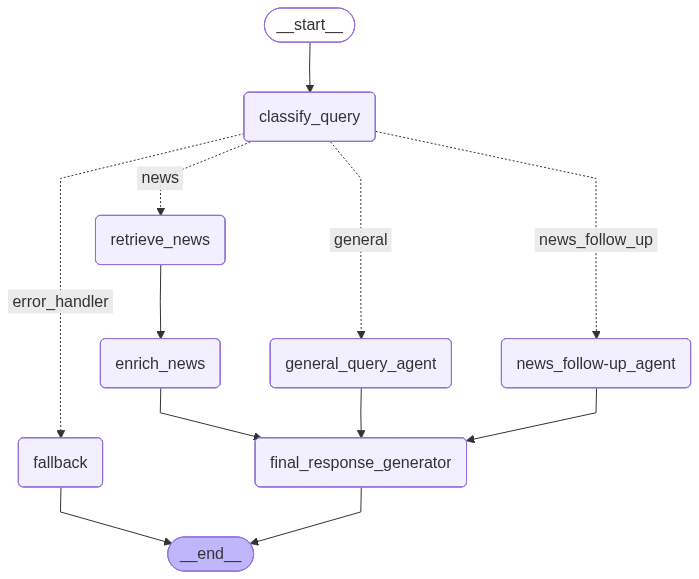

In [20]:
builder = StateGraph(NewsGenieState)

builder.add_node(
    "classify_query",
    classify_query_node
)

builder.add_node(
    "general_query_agent",
    general_query_node
)

builder.add_node(
    "news_follow-up_agent",
    news_followup_node
)

builder.add_node(
    "retrieve_news",
    retrieve_news_node
)

builder.add_node(
    "enrich_news",
    enrich_news_node
)

builder.add_node(
    "final_response_generator",
    final_response_node
)

builder.add_node(
    "fallback",
    error_handler_node
)

builder.add_edge(START,"classify_query")

builder.add_conditional_edges(
                                "classify_query",
                                route_query,
                                {
                                    "error_handler": "fallback",
                                    "news": "retrieve_news",
                                    "general": "general_query_agent",
                                    "news_follow_up": "news_follow-up_agent"
                                }
                            )

builder.add_edge("retrieve_news", "enrich_news")

builder.add_edge("enrich_news","final_response_generator")

builder.add_edge("news_follow-up_agent","final_response_generator")

builder.add_edge("general_query_agent","final_response_generator")

builder.add_edge("final_response_generator",END)

builder.add_edge("fallback",END)

graph = builder.compile(checkpointer=memory)
graph

---
## Setup UI using Gradio

In [21]:
CHAT_ENABLED = all([OPENAI_API_KEY, NEWS_API_KEY, TAVILY_API_KEY])

# ==================================================
# Chat Function
# ==================================================

# Helper Function to convert coversation stored as messages in dict format which can be rendered in UI
def messages_to_chat_history(messages):

    chat_history = []

    for msg in messages:

        if isinstance(msg, HumanMessage):

            chat_history.append(
                {
                    "role": "user",
                    "content": msg.content
                }
            )

        elif isinstance(msg, AIMessage):

            chat_history.append(
                {
                    "role": "assistant",
                    "content": msg.content
                }
            )

    return chat_history

# Define Chat Function which will be triggered from UI and would invoke the Graph
def newsgenie_chat(
    user_message,
    chat_history, 
    category,
    openai_key,
    newsapi_key,
    tavily_key,
    session_thread_id
):

    try:

        # ==========================================
        # Runtime API Keys
        # ==========================================

        os.environ["OPENAI_API_KEY"] = openai_key
        os.environ["NEWS_API_KEY"] = newsapi_key
        os.environ["TAVILY_API_KEY"] = tavily_key


        # ==========================================
        # Empty Input Check
        # ==========================================

        if not user_message or not user_message.strip():

            return "", chat_history, ""


        # ==========================================
        # LangGraph Thread Configuration
        # ==========================================

        config = {
            "configurable": {
                "thread_id": session_thread_id
            }
        }

        # ==========================================
        # Invoke Graph
        # ==========================================

        graph_result = graph.invoke(
            {
                "user_query": user_message,
                "news_category": category
            },
            config=config
        )

        query_type = graph_result.get("query_type", "unknown")
        query_intent = graph_result.get("query_intent", "unknown")

        query_type_display = (f"{query_type} ({query_intent})")

        # ==========================================
        # Load Full Conversation From SQLite
        # ==========================================

        snapshot = graph.get_state(config)

        messages = snapshot.values.get(
            "messages",
            []
        )

        # ==========================================
        # Convert Messages → Gradio Format
        # ==========================================

        chat_history = messages_to_chat_history(
            messages
        )

        return "", chat_history, query_type_display

    except Exception as e:

        error_history = [
            {
                "role": "assistant",
                "content": f"❌ Error: {str(e)}"
            }
        ]

        return "", error_history, ""


# ==================================================
# Toggle Chat Area
# ==================================================

def toggle_chat(openai_key, news_api_key, tavily_key):
    enabled = all(
        [
            openai_key and openai_key.strip(),
            news_api_key and news_api_key.strip(),
            tavily_key and tavily_key.strip()
        ]
    )

    return (
        gr.update(visible=enabled),       # Targets: chat_content
        gr.update(visible=not enabled)    # Targets: empty_state
    )


# ==================================================
# New Chat
# ==================================================

def new_chat():
    return (
        [],                # Clears chat_history
        "0",               # Resets message_count
        str(uuid.uuid4()),  # Overwrites session_thread_id State
        "",               # Clears current_query
        ""                # Clears query_type_display
    )


# ==================================================
# Message Counter
# ==================================================

def update_message_count(chat_history):
    
    chat_history = chat_history or []
    
    user_count = sum(
        1
        for msg in chat_history
        if msg.get("role") == "user"
    )

    return str(user_count)


# ==================================================
# Update Current Query Display
# ==================================================

def update_current_query(user_message):
    return user_message

# ==================================================
# UI Layout
# ==================================================

with gr.Blocks(title="NewsGenie") as app:

    # Invisible unique tracking ID for separate browser tabs
    session_thread_id = gr.State(lambda: str(uuid.uuid4()))

    gr.Markdown(
        """
        # 📰 NewsGenie
        ## AI Assistant for News & General Knowledge
        """
    )

    with gr.Row():

        # ==========================================
        # LEFT PANEL
        # ==========================================
        with gr.Column(scale=1, min_width=250):

            gr.Markdown("### API Configuration")

            openai_key = gr.Textbox(
                label="OpenAI Key",
                value=OPENAI_API_KEY,
                type="password",
                placeholder="Enter OpenAI Key"
            )

            newsapi_key = gr.Textbox(
                label="NewsAPI Key",
                value=NEWS_API_KEY,
                type="password",
                placeholder="Enter NewsAPI Key"
            )

            tavily_key = gr.Textbox(
                label="Tavily Key",
                value=TAVILY_API_KEY,
                type="password",
                placeholder="Enter Tavily Key"
            )

            gr.Markdown("---")
            gr.Markdown("### Current Session")

            message_count = gr.Textbox(
                label="Conversation Turns",
                value="0",
                interactive=False
            )

            query_type_display = gr.Textbox(
                label="Current Query Type",
                value="",
                interactive=False,
                lines=1
            )
            
            new_chat_btn = gr.Button("🆕 New Chat")

            category = gr.Dropdown(
                label="News Category",
                choices=[
                    ("General", "general"),
                    ("Technology", "technology"),
                    ("Finance", "business"),
                    ("Science", "science"),
                    ("Sports", "sports"),
                    ("Health", "health"),
                    ("Entertainment", "entertainment")
                ],
                value="general"
            )

            gr.Markdown("---")

        # ==========================================
        # RIGHT PANEL
        # ==========================================
        with gr.Column(scale=4):

            # Setup Display State
            empty_state = gr.Markdown(
                """
                ## 🔑 Configure API Keys

                Please provide:
                - OpenAI API Key
                - NewsAPI Key
                - Tavily API Key

                The chat interface will appear automatically.
                """,
                visible=not CHAT_ENABLED
            )

            # Active Chat Interface Container
            with gr.Column(visible=CHAT_ENABLED) as chat_content:

                chat_history = gr.Chatbot(
                    label="Chat History",
                    height=535
                )

                gr.Markdown("### Current Query")

                current_query = gr.Textbox(
                    value="",
                    placeholder="No active query",
                    interactive=False,
                    lines=1,
                    show_label=False
                )
                
                with gr.Row():
                    user_message = gr.Textbox(
                        placeholder="Ask anything...",
                        show_label=False,
                        scale=8
                    )
                    send_btn = gr.Button(
                        "Send",
                        scale=1
                    )

    # ==================================================
    # API Key Change Events
    # ==================================================

    for component in [openai_key, newsapi_key, tavily_key]:
        component.change(
            fn=toggle_chat,
            inputs=[openai_key, newsapi_key, tavily_key],
            outputs=[chat_content, empty_state]
        )

    # ==================================================
    # Chat Events (Separated Explicitly)
    # ==================================================

    # 1. Send Button Click Action Pipeline
    send_btn.click(
        fn=update_current_query,
        inputs=user_message,
        outputs=current_query,
        queue=False
    ).then(
        fn=newsgenie_chat,
        inputs=[
            user_message,
            chat_history,
            category,
            openai_key,
            newsapi_key,
            tavily_key,
            session_thread_id
        ],
        outputs=[
            user_message,
            chat_history,
            query_type_display
        ]

    ).then(
        fn=update_message_count,
        inputs=chat_history,
        outputs=message_count,
        queue=False
    )

    # 2. Textbox Keyboard Enter Action Pipeline
    user_message.submit(
        fn=update_current_query,
        inputs=user_message,
        outputs=current_query,
        queue=False
    ).then(
        fn=newsgenie_chat,
        inputs=[
            user_message,
            chat_history,
            category,
            openai_key,
            newsapi_key,
            tavily_key,
            session_thread_id
        ],
        outputs=[
            user_message,
            chat_history,
            query_type_display
        ]
    ).then(
        fn=update_message_count,
        inputs=chat_history,
        outputs=message_count,
        queue=False
    )

    # ==================================================
    # New Chat Session Reset
    # ==================================================

    new_chat_btn.click(
        fn=new_chat,
        outputs=[
            chat_history,
            message_count,
            session_thread_id,
            current_query,
            query_type_display
        ]
    )

---
## Launch App

In [25]:
app.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [26]:
app.close()

Closing server running on port: 7860
